In [ ]:
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns


# Clustering
from sklearn.cluster import KMeans

DATA = "data/CrashData.csv"
# Load the dataset
data = pd.read_csv(DATA)

In [27]:
print(data.columns)

Index(['OBJECTID', 'Document_Nbr', 'Crash_Year', 'Crash_Severity',
       'Driver_VehicleNumber', 'Driver_InjuryType', 'Driver_Age',
       'Driver_Gender', 'Driver_Action_Type_Cd', 'Driver_Airbag_Deployment',
       'Driver_Alcohol_Test_Type_Cd', 'Driver_Condition_Type_Cd',
       'Driver_Distraction_Type_Cd', 'Driver_Drinking_Type_Cd',
       'Driver_Drug_Use_Cd', 'Driver_Ejected_From_Vehicle',
       'Driver_Ems_Transport_Ind', 'Driver_Fled_Scene_Ind',
       'Driver_Safety_Equip_Used', 'Driver_Vis_Obscured_Type_Cd',
       'Summons_Issued_Cd', 'Vehiclenumber', 'Vehicle_Body_Type_Cd',
       'Vehicle_Make_Nm', 'Vehicle_Maneuver_Type_Cd', 'Vehicle_Model_Nm',
       'Vehicle_Year_Nbr', 'Comm_Cargo_Body_Type_Cd',
       'Comm_Vehicle_Body_Type_Cd', 'Speed_Before', 'Speed_Posted',
       'Speed_Max_Safe', 'First_Crash_Event_Cd', 'Second_Crash_Event_Cd',
       'Third_Crash_Event_Cd', 'Fourth_Crash_Event_Cd',
       'Most_Harmful_Crash_Event_Cd', 'Initial_Veh_Impact_Area_Cd',
       'Dir

In [15]:

data_sample = data.sample(1000)
pass

In [20]:
for index, row in data.iterrows():
    # gender is a semi-colon separated string
    # set the 'Primary_Gender' column to the first non-n/a value

    gender_string = row['Driver_Gender']
    gender_values = gender_string.split(';')
    for gender in gender_values:
        if gender != 'n/a':
            data.at[index, 'Primary_Gender'] = gender
            continue




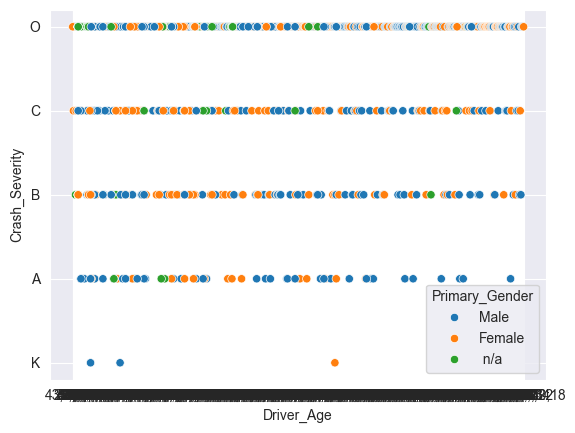

In [18]:
# scatterplot of crash severity vs driver age, colored by gender
sns.scatterplot(data=data_sample, x='Driver_Age', y='Crash_Severity', hue='Primary_Gender')
plt.show()

In [21]:
# print the frequency of male vs female drivers
print(data['Primary_Gender'].value_counts())

Primary_Gender
Male      445720
Female    340282
 n/a       58690
Name: count, dtype: int64


In [43]:
for index, row in data_sample.iterrows():
    # gender is a semi-colon separated string
    # set the 'Primary_Gender' column to the first non-n/a value

    speed_str = row['Speed_Before']
    if type(speed_str) != str:
        data_sample.at[index, 'Max_Speed'] = speed_str
        continue
    spdval = speed_str.split(';')
    spdval_int = [int(x) for x in spdval if x.isdigit()]
    data_sample.at[index, 'Max_Speed'] = max(spdval_int) if len(spdval_int) > 0 and max(spdval_int) < 200 else None

<Axes: xlabel='Max_Speed', ylabel='Crash_Severity'>

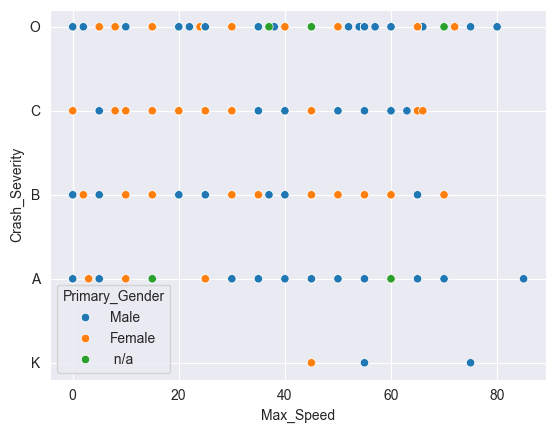

In [44]:
sns.scatterplot(data=data_sample, x='Max_Speed', y='Crash_Severity', hue='Primary_Gender')

In [48]:
# print average speed for each crash severity
print(data_sample.groupby('Crash_Severity')['Max_Speed'].mean())

Crash_Severity
A    38.271186
B    35.425197
C    30.118881
K    58.333333
O    33.122291
Name: Max_Speed, dtype: object


In [49]:
print(data['Vehicle_Body_Type_Cd'].value_counts())

Vehicle_Body_Type_Cd
1. Passenger car;1. Passenger car                                                                                                                    169463
1. Passenger car                                                                                                                                     138822
1. Passenger car;22. Truck (SUV)                                                                                                                      53621
22. Truck (SUV);1. Passenger car                                                                                                                      42202
22. Truck (SUV)                                                                                                                                       41386
                                                                                                                                                      ...  
12. Emergency Vehicle (Regardless of Veh Ty

In [50]:
print(data['Route or Street Name'].value_counts())

Route or Street Name
I-95 SOUTH                        2847
I-95 NORTH                        2737
I-95                              2719
I-64 EAST                         2665
I-64 WEST                         2642
                                  ... 
1294 w ocean view ave                1
RT 666 SOUTHBOUND                    1
1400 BLK CAPOSTELLA ROAD             1
7700 GrANbY ST                       1
ON RAMP TP 495 NORTH AND SOUTH       1
Name: count, Length: 234224, dtype: int64
